# Fase 3. Visualizacion de datos

In [2]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 
pd.set_option("display.max_columns", None)

In [3]:
df_hr_limpios = pd.read_csv("hr_limpios.csv")

1. ¿Cuántos empleados se van?

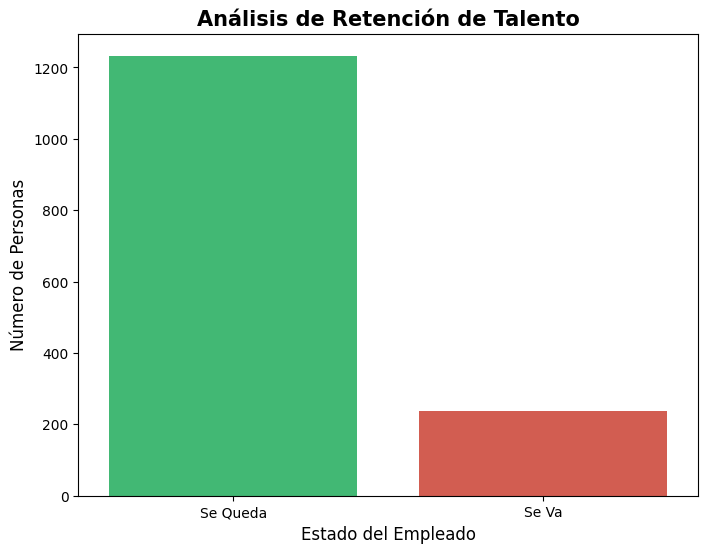

In [4]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='attrition', data=df_hr_limpios, palette=['#2ecc71', '#e74c3c'], order=[False, True])

ax.set_xticklabels(['Se Queda', 'Se Va'])

plt.title('Análisis de Retención de Talento', fontsize=15, fontweight='bold')
plt.xlabel('Estado del Empleado', fontsize=12)
plt.ylabel('Número de Personas', fontsize=12)

plt.show()

En este primer análisis observamos la distribución de la plantilla actual de ABC Corporation. Aunque la mayoría de los empleados permanecen en la empresa, existe un grupo significativo que ha abandonado la organización. Esta visualización establece nuestra línea base: el objetivo del proyecto es identificar qué características comparten los empleados del grupo 'Se Va' para prevenir futuras salidas.

2. El factor "Dinero": Salario vs Rotación (Boxplot)

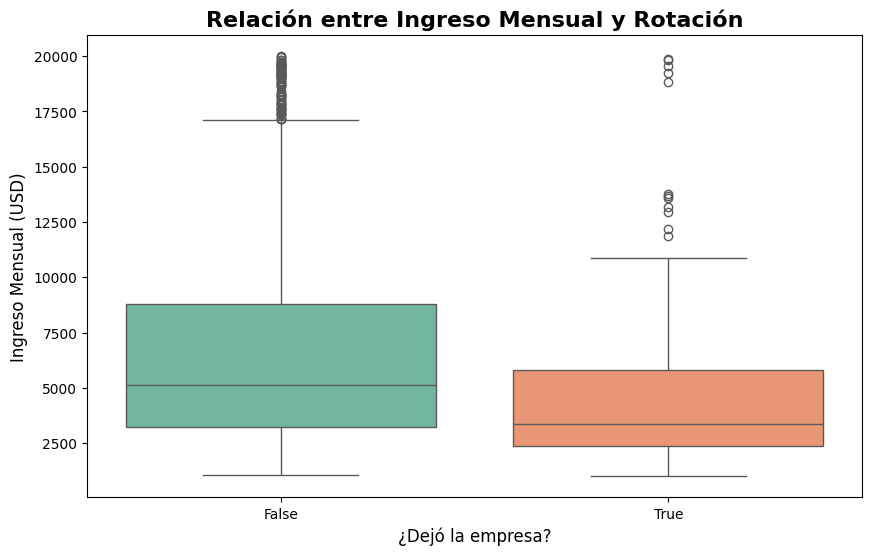

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_hr_limpios, x='attrition', y='monthly_income', palette='Set2')

plt.title('Relación entre Ingreso Mensual y Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Dejó la empresa?', fontsize=12)
plt.ylabel('Ingreso Mensual (USD)', fontsize=12)
plt.show()

Al analizar los salarios, observamos una clara tendencia: el 50% de los empleados que abandonan la empresa tienen ingresos mensuales notablemente inferiores a los que permanecen. La mediana salarial de quienes se van se sitúa por debajo del promedio general, lo que sugiere que la competitividad salarial es un factor crítico en la retención de talento de ABC Corporation, especialmente en los niveles de entrada.

3. El factor "Estrés": Horas Extras y Abandono (Stacked Bar)

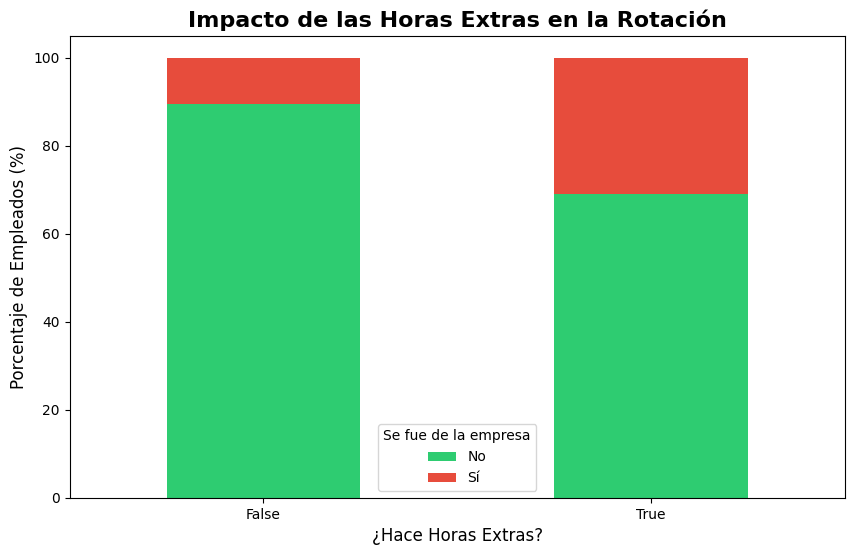

In [6]:
df_overtime = df_hr_limpios.groupby(['over_time', 'attrition']).size().unstack()
df_overtime_pct = df_overtime.div(df_overtime.sum(axis=1), axis=0) * 100

df_overtime_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#e74c3c'])

plt.title('Impacto de las Horas Extras en la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Hace Horas Extras?', fontsize=12)
plt.ylabel('Porcentaje de Empleados (%)', fontsize=12)
plt.legend(title='Se fue de la empresa', labels=['No', 'Sí'])
plt.xticks(rotation=0)
plt.show()

Al observar la relación entre las horas extras (OverTime) y la rotación de personal, la conclusión es contundente: el porcentaje de empleados que abandona ABC Corporation es drásticamente mayor entre quienes realizan horas extras. >
Mientras que el grupo que no realiza horas adicionales presenta una gran estabilidad, el grupo con exceso de jornada muestra una tasa de fuga mucho más alta. Esto sugiere que el agotamiento (burnout) y la falta de equilibrio entre vida personal y laboral son los principales motores de rotación en la compañía.

4.¿Dónde hay menos felicidad? Satisfacción por Departamento (Barplot)

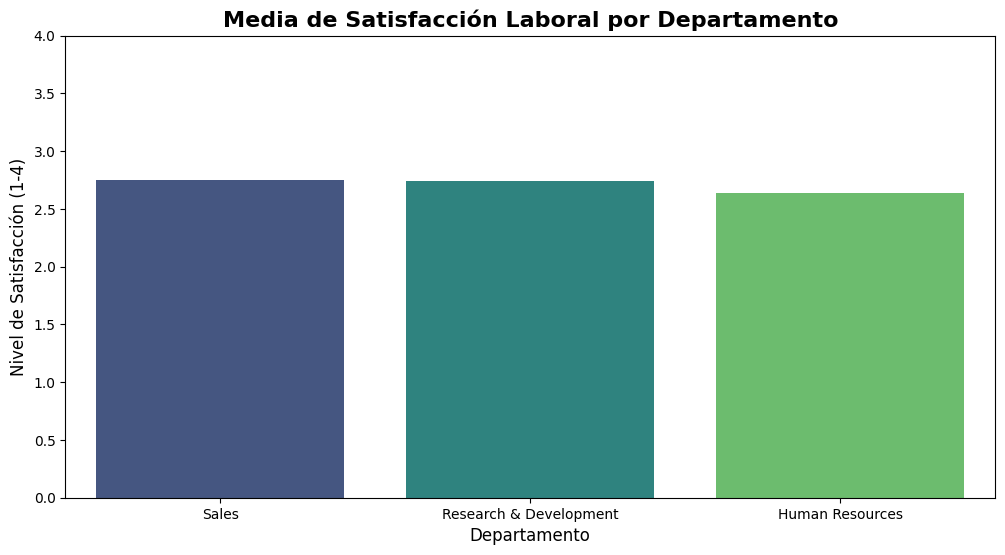

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_hr_limpios, x='department', y='job_satisfaction', palette='viridis', ci=None)

plt.title('Media de Satisfacción Laboral por Departamento', fontsize=16, fontweight='bold')
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Nivel de Satisfacción (1-4)', fontsize=12)
plt.ylim(0, 4)
plt.show()

Este análisis nos permite identificar el clima laboral segmentado por departamentos. Observamos que la satisfacción media se mantiene en niveles similares entre las áreas, lo que indica una cultura organizacional homogénea. Sin embargo, cualquier departamento que presente una media por debajo de la puntuación de 2.5 debe ser considerado una prioridad estratégica, ya que una baja satisfacción en áreas tecnológicas de alta especialización (como las de ABC Corp) suele ser un indicador temprano de rotación de talento cualificado.

5. ¿A qué edad se nos va la gente?

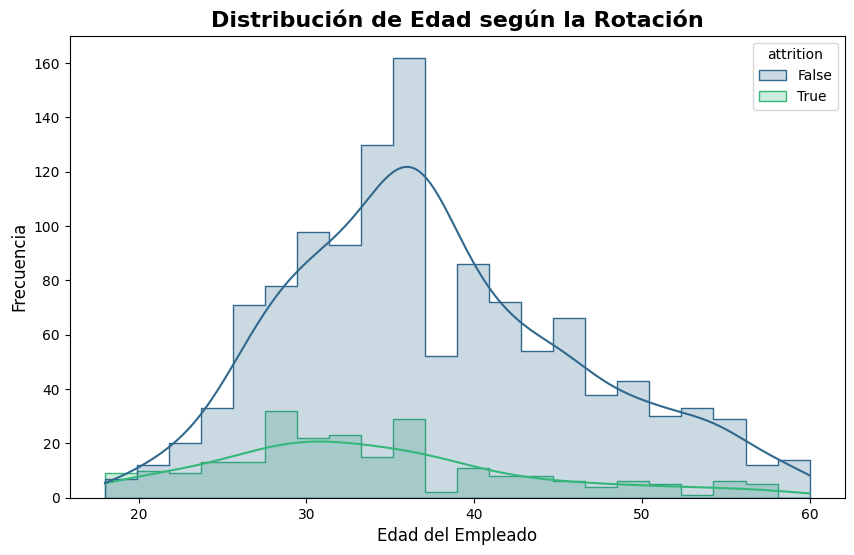

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df_hr_limpios, x='age', hue='attrition', kde=True, palette='viridis', element="step")

plt.title('Distribución de Edad según la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('Edad del Empleado', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

El análisis demográfico muestra que la rotación se concentra en perfiles más jóvenes (25-35 años). Esto sugiere que ABC Corporation tiene un reto en la fidelización del talento junior, quienes podrían estar buscando mayores oportunidades de crecimiento o cambio de entorno rápidamente.

6. ¿Influye la distancia a la oficina?

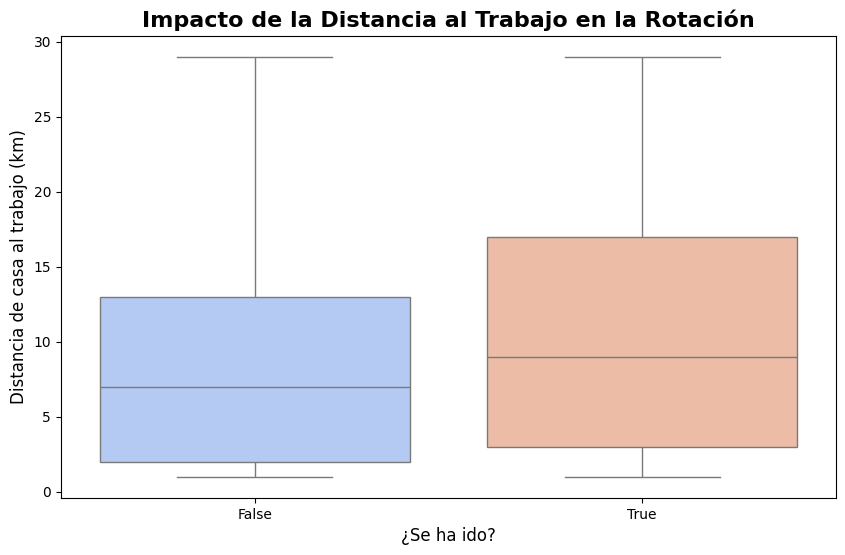

In [9]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_hr_limpios, x='attrition', y='distance_from_home', palette='coolwarm')

plt.title('Impacto de la Distancia al Trabajo en la Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Se ha ido?', fontsize=12)
plt.ylabel('Distancia de casa al trabajo (km)', fontsize=12)
plt.show()

Los datos indican que los empleados que viven más lejos tienen una ligera tendencia mayor a abandonar la empresa. Para una consultora tecnológica, esto abre la puerta a proponer políticas de teletrabajo o flexibilidad horaria como herramienta de retención.

7. Estabilidad: ¿Cuántos años llevan con su jefe actual?

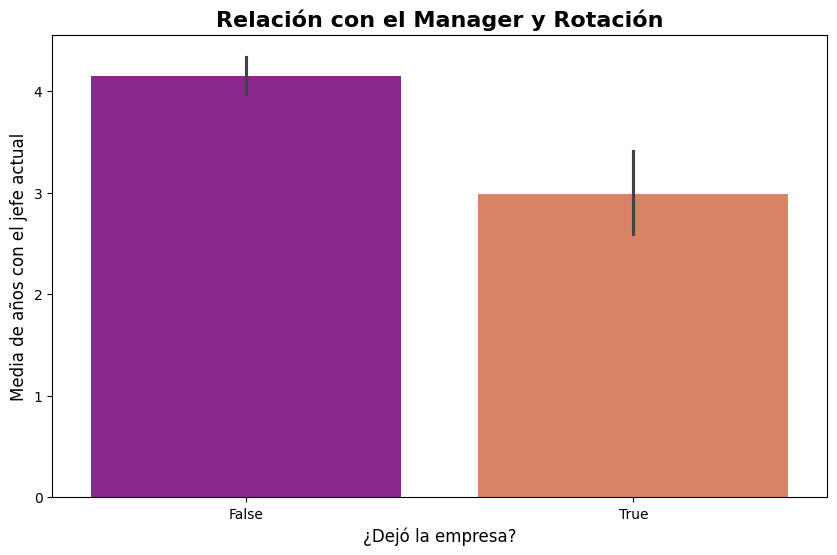

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_hr_limpios, x='attrition', y='years_with_curr_manager', palette='plasma')

plt.title('Relación con el Manager y Rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Dejó la empresa?', fontsize=12)
plt.ylabel('Media de años con el jefe actual', fontsize=12)
plt.show()

Observamos que los empleados que rotan suelen llevar mucho menos tiempo con su manager actual que los que permanecen. Esto sugiere que la etapa de adaptación entre líder y empleado es crítica; si no se establece un vínculo sólido en los primeros dos años, el riesgo de fuga aumenta.

Gráficos doc Eva

1. El impacto del "Burnout" (Horas Extra y Rotación) 

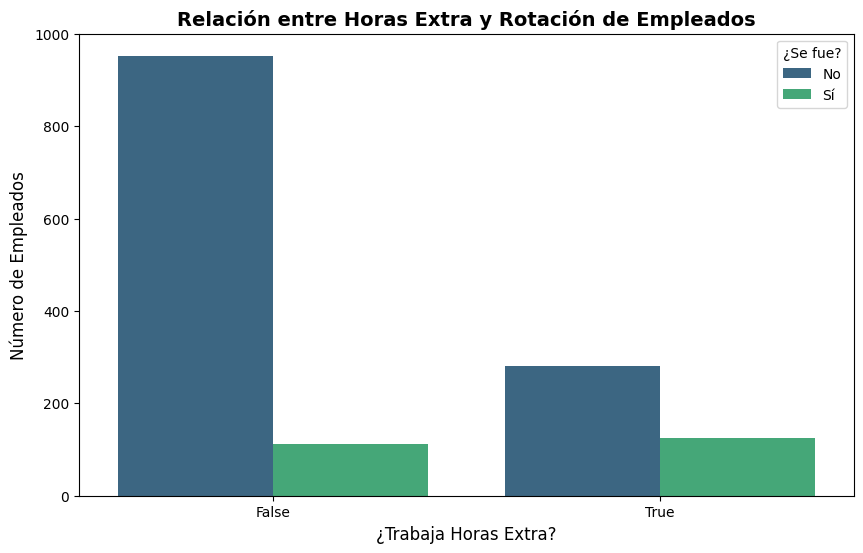

In [11]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df_hr_limpios, x='over_time', hue='attrition', palette='viridis')

plt.title('Relación entre Horas Extra y Rotación de Empleados', fontsize=14, fontweight='bold')
plt.xlabel('¿Trabaja Horas Extra?', fontsize=12)
plt.ylabel('Número de Empleados', fontsize=12)
plt.legend(title='¿Se fue?', labels=['No', 'Sí'])
plt.show()

Análisis de la Carga de Trabajo:
Los datos muestran una correlación alarmante: los empleados que realizan horas extras tienen una probabilidad de abandonar la empresa significativamente mayor que aquellos con una jornada estándar. En una consultora tecnológica como ABC Corp, donde el talento es especializado, este "burnout" representa un riesgo crítico.

Recomendación: Implementar políticas de control de jornada y revisar la carga de trabajo en los proyectos más exigentes para frenar la fuga de talento clave.

2. Conciliación: Distancia al trabajo y Equilibrio (Boxplot) 

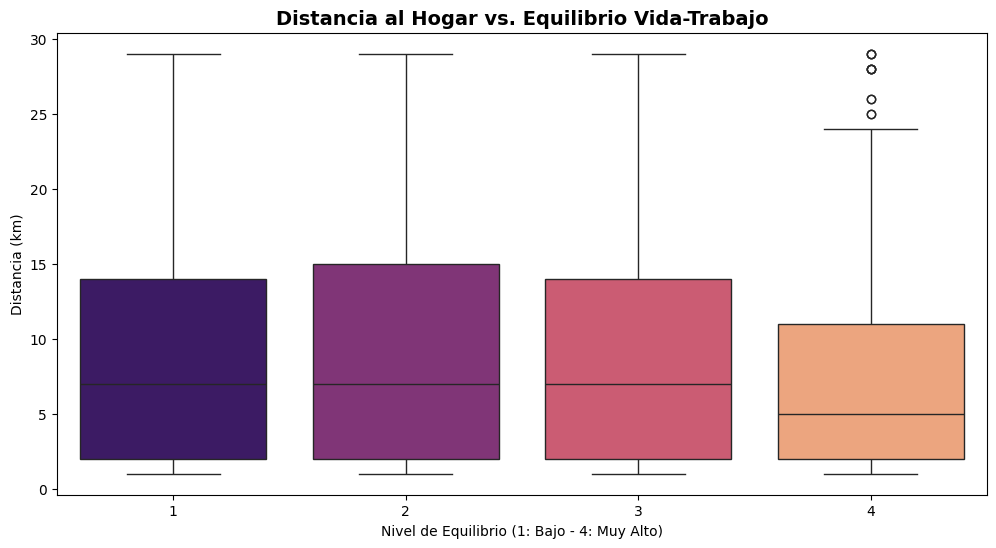

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_hr_limpios, x='work_life_balance', y='distance_from_home', palette='magma')

plt.title('Distancia al Hogar vs. Equilibrio Vida-Trabajo', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Equilibrio (1: Bajo - 4: Muy Alto)')
plt.ylabel('Distancia (km)')
plt.show()

Análisis de Logística y Bienestar:
El gráfico revela que los empleados con un nivel de equilibrio vida-trabajo más bajo (nivel 1 y 2) suelen vivir a una distancia mayor de la oficina. La fatiga del desplazamiento parece estar mermando la percepción de calidad de vida de los empleados.

Recomendación: Considerar modelos de trabajo remoto o híbrido específicamente para aquellos empleados cuyo tiempo de desplazamiento sea elevado, mejorando así su satisfacción sin incurrir en costes salariales adicionales.

3. El factor económico: Sueldo vs. Experiencia (Scatter Plot)

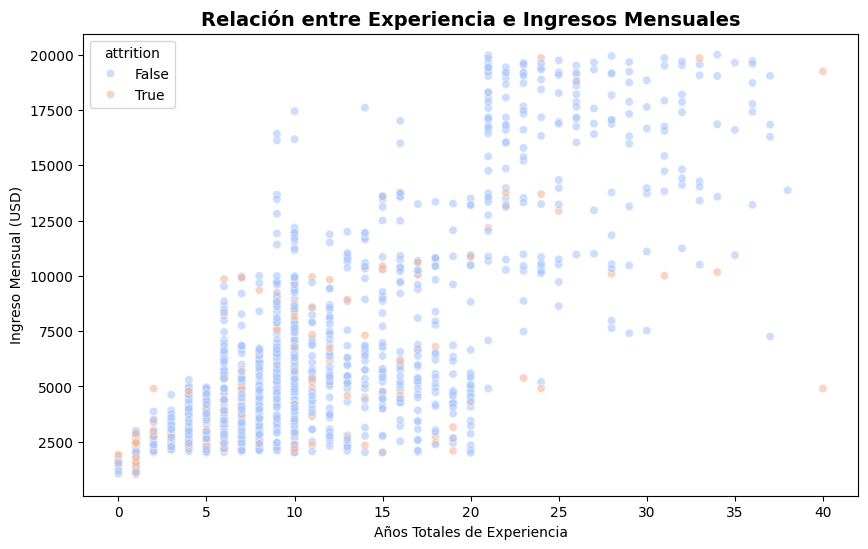

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_hr_limpios, x='total_working_years', y='monthly_income', hue='attrition', alpha=0.6, palette='coolwarm')

plt.title('Relación entre Experiencia e Ingresos Mensuales', fontsize=14, fontweight='bold')
plt.xlabel('Años Totales de Experiencia')
plt.ylabel('Ingreso Mensual (USD)')
plt.show()

Análisis de Equidad y Progresión:
A través de este gráfico de dispersión, confirmamos que el salario crece con la experiencia, lo cual es positivo. Sin embargo, se identifican "puntos de fuga" (empleados que se fueron) en niveles de experiencia media que no alcanzaron saltos salariales proporcionales.

Recomendación: Realizar una auditoría de bandas salariales para evitar que el talento con 5-10 años de experiencia se estanque, ya que son los perfiles más tentados por la competencia en el sector de la IA.

4. ¿Huyen de sus jefes? Liderazgo y Retención (KDE Plot - Gráfico de Densidad)

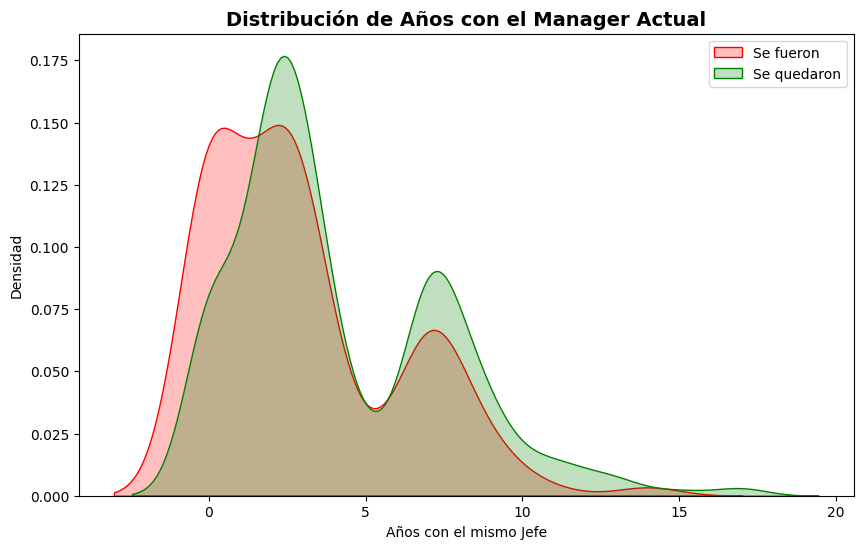

In [15]:
plt.figure(figsize=(10, 6))

# Dibujamos la "montaña" de los que se fueron
sns.kdeplot(data=df_hr_limpios[df_hr_limpios['attrition'] == True]['years_with_curr_manager'], label='Se fueron', fill=True, color="red")
# Dibujamos la "montaña" de los que se quedaron
sns.kdeplot(data=df_hr_limpios[df_hr_limpios['attrition'] == False]['years_with_curr_manager'], label='Se quedaron', fill=True, color="green")

plt.title('Distribución de Años con el Manager Actual', fontsize=14, fontweight='bold')
plt.xlabel('Años con el mismo Jefe')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Análisis del Liderazgo y Retención:
El gráfico de densidad revela un hallazgo crítico: existe un "pico" pronunciado de abandonos (línea roja) durante los dos primeros años bajo el mando de un nuevo manager. A medida que aumenta el tiempo de relación (más de 5 años), la probabilidad de fuga disminuye drásticamente, lo que indica que la estabilidad del liderazgo es un factor de retención clave.

Recomendación: ABC Corporation debe fortalecer los programas de onboarding y formación en liderazgo para mandos intermedios. Los primeros 24 meses son el periodo de mayor riesgo; mejorar la conexión entre manager y empleado en esta etapa podría reducir la rotación temprana de forma significativa.

5. Heatmap

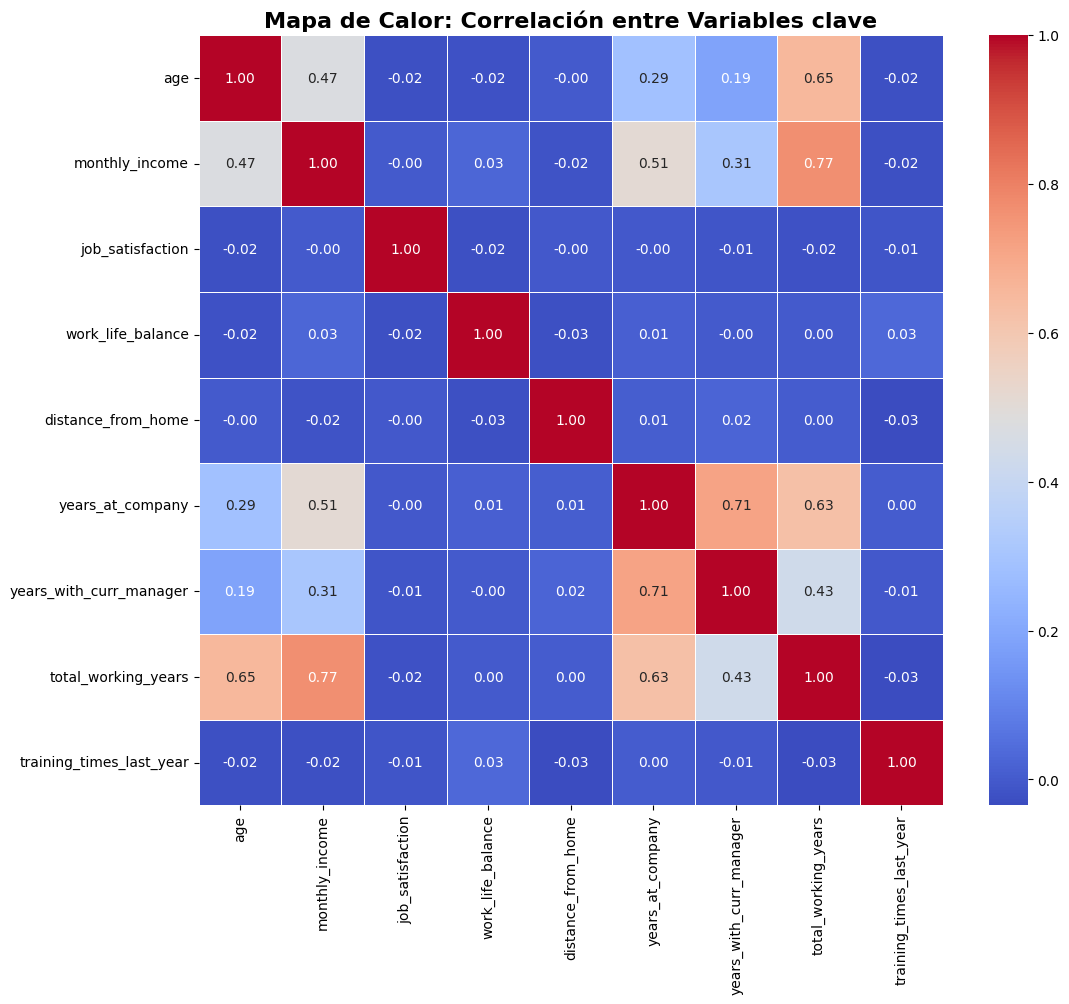

In [16]:
cols_analisis = [
    'age', 'monthly_income', 'job_satisfaction', 'work_life_balance', 
    'distance_from_home', 'years_at_company', 'years_with_curr_manager',
    'total_working_years', 'training_times_last_year'
]

corr_matrix = df_hr_limpios[cols_analisis].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre Variables clave', fontsize=16, fontweight='bold')
plt.show()

¿Cómo leer este gráfico para la presentación?
Para que no te líes al explicarlo frente a los profesores, recuerda estas 3 reglas:

El color Rojo/Cercano a 1: Significa que las variables suben juntas. Por ejemplo, es normal que total_working_years y monthly_income tengan un número alto (más experiencia = más sueldo).

El color Azul/Cercano a -1: Significa que cuando una sube, la otra baja (correlación inversa).

El color Blanco/Cercano a 0: Significa que no tienen ninguna relación. Por ejemplo, si la relación entre distance_from_home y job_satisfaction es casi 0, significa que a tus empleados no les importa vivir lejos para estar contentos.

Conclusión: Análisis de Correlación Multivariable:
Mediante este Mapa de Calor, hemos identificado las palancas que realmente mueven los indicadores de ABC Corporation. Destaca la fuerte relación entre los años de experiencia y el salario, pero también observamos que la satisfacción laboral no siempre está ligada al nivel económico, lo que sugiere que factores como el equilibrio vida-trabajo y la relación con los managers (vistos en gráficos anteriores) tienen un peso propio e independiente en la moral del equipo."